In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [2]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2)

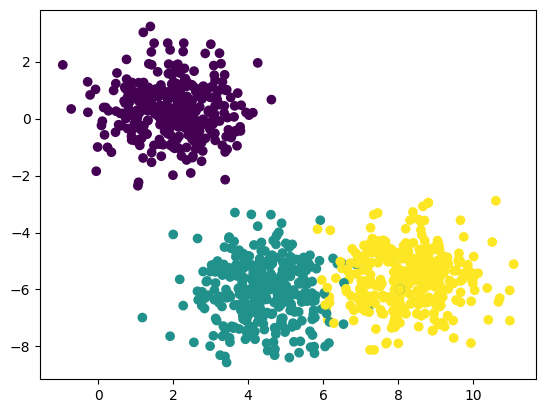

In [4]:
plt.scatter(X[:,0], X[:,1], c=y)

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [6]:
# Standardization--feature scaling technique
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [7]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [8]:
from sklearn.cluster import KMeans

In [ ]:
# Elbow method to select K value
wcss=[]
for k in range(1,11):
  kmeans=KMeans(n_clusters=k,init='k-means++')
  kmeans.fit(X_train_scaled)
  wcss.append(kmeans.inertia_)  # This is the inertia, which in scikit-learn is the sum of squared distances of each sample to its assigned cluster centroid.

In [10]:
wcss

[1340.0000000000016,
 369.8786941564101,
 146.56679937109337,
 127.00202769207544,
 111.05445666384061,
 102.99725260107337,
 85.1341471960733,
 81.69073844152754,
 62.680769376742056,
 59.74719468101237]

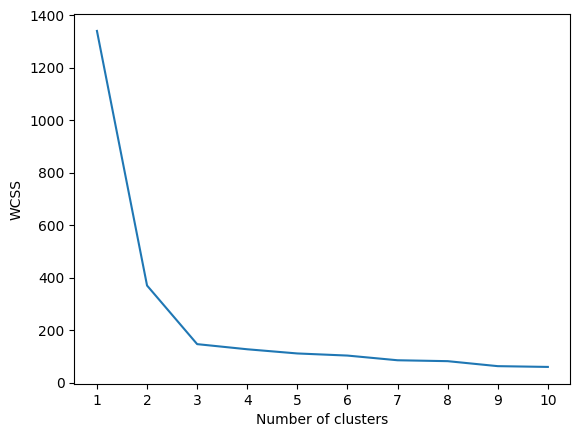

In [11]:
# Plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

In [12]:
kmeans = KMeans(n_clusters=3,init='k-means++')

In [13]:
kmeans.fit_predict(X_train_scaled)

array([2, 2, 2, 0, 2, 0, 0, 1, 1, 1, 2, 2, 2, 0, 1, 2, 0, 1, 1, 1, 1, 2,
       1, 2, 2, 0, 2, 0, 1, 2, 0, 1, 2, 2, 1, 0, 2, 2, 0, 2, 1, 1, 0, 2,
       1, 1, 1, 0, 1, 1, 1, 2, 2, 2, 2, 2, 0, 0, 2, 2, 0, 1, 0, 2, 1, 0,
       2, 2, 1, 1, 1, 1, 1, 0, 2, 2, 2, 0, 2, 1, 0, 0, 2, 2, 2, 1, 1, 2,
       2, 1, 1, 0, 2, 2, 0, 1, 2, 0, 0, 0, 0, 2, 2, 1, 0, 0, 2, 2, 2, 0,
       2, 2, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 2, 2, 0, 1, 1, 2, 1, 1, 1,
       2, 0, 1, 2, 1, 0, 2, 2, 2, 1, 1, 2, 2, 1, 1, 2, 1, 2, 0, 2, 1, 1,
       2, 0, 2, 1, 0, 2, 0, 1, 2, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       2, 1, 1, 0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0, 1, 1, 0, 0, 0, 2, 2, 2,
       1, 2, 1, 2, 0, 2, 2, 2, 2, 1, 0, 2, 0, 1, 0, 1, 1, 1, 0, 0, 2, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 2, 1, 1, 2, 1, 0, 2, 1, 1, 2, 0,
       2, 0, 0, 1, 2, 1, 2, 1, 2, 2, 0, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 2,
       1, 0, 0, 0, 0, 2, 2, 2, 0, 2, 0, 2, 1, 1, 2, 0, 2, 1, 0, 2, 0, 2,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 1, 2, 2, 2,

In [14]:
y_pred=kmeans.predict(X_test_scaled)

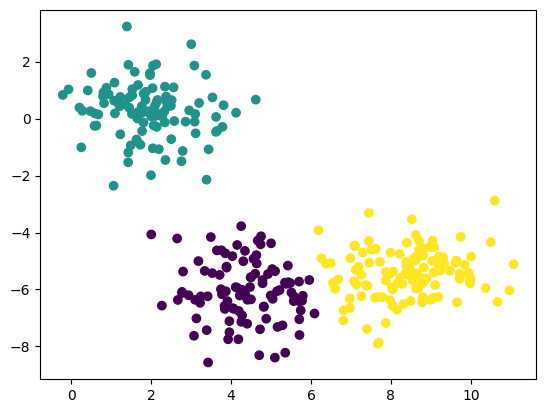

In [16]:
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred)

In [ ]:
## Validating the k value
## KneeLocator
## Silhoutee scoring

In [18]:
from kneed import KneeLocator
kl=KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')

In [19]:
kl.elbow

np.int64(3)

In [20]:
# Silhoutte score
from sklearn.metrics import silhouette_score

In [21]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

# Silhouette Score measures: How well each data point fits inside its assigned cluster compared with other clusters.

In [23]:
silhouette_coefficients

[0.6555265950092435,
 0.6381352664594017,
 0.5092737459100116,
 0.4613436044004766,
 0.37060331154975656,
 0.3397128539006334,
 0.34308210379532383,
 0.31896316635347816,
 0.3285012521406517]

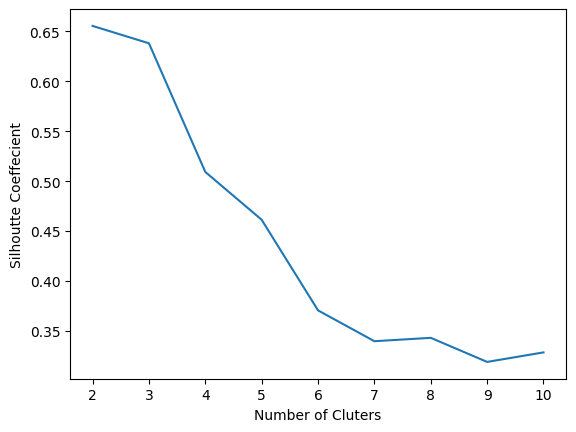

In [ ]:
# Plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()

# there is a sharp drop in values from k=3, therefore that is our k-value.